In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [24]:
df=pd.read_csv('C:\\Users\\MOSTAFA\\insurance (1).csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [25]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [26]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [28]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [29]:
df.shape

(1338, 7)

In [30]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [31]:
print(df.duplicated().sum())

1


In [32]:
df.drop_duplicates(inplace=True)

In [33]:
print(df.duplicated().sum())

0


In [34]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [35]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [36]:
(df == '?').sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [37]:
(df == 'nan').sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [38]:
(df == 'NaN').sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [39]:
(df == 'null').sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [40]:
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers in {col}:")
    print(outliers)
    print("-" * 50)

Outliers in age:
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
--------------------------------------------------
Outliers in bmi:
      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270
--------------------------------------------------
Outliers in children:
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
----------

In [41]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Q1 = 27.0
Q3 = 51.0
IQR = 24.0
Lower Bound = -9.0
Upper Bound = 87.0


In [42]:
num_cols = df.select_dtypes(include=[np.number]).columns

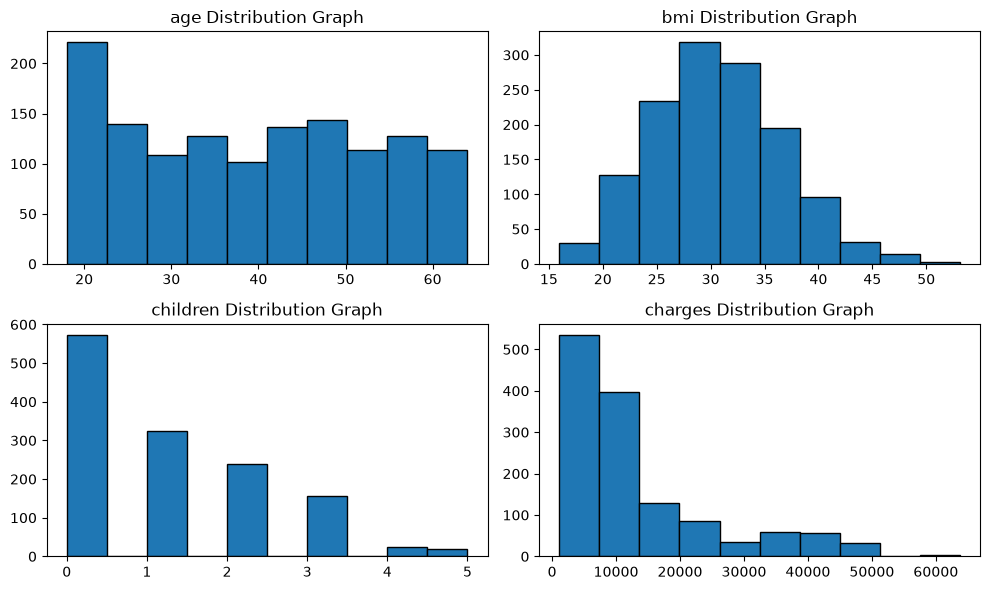

In [43]:
plt.figure(figsize=(10, 6))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} Distribution Graph")

plt.tight_layout()
plt.show()

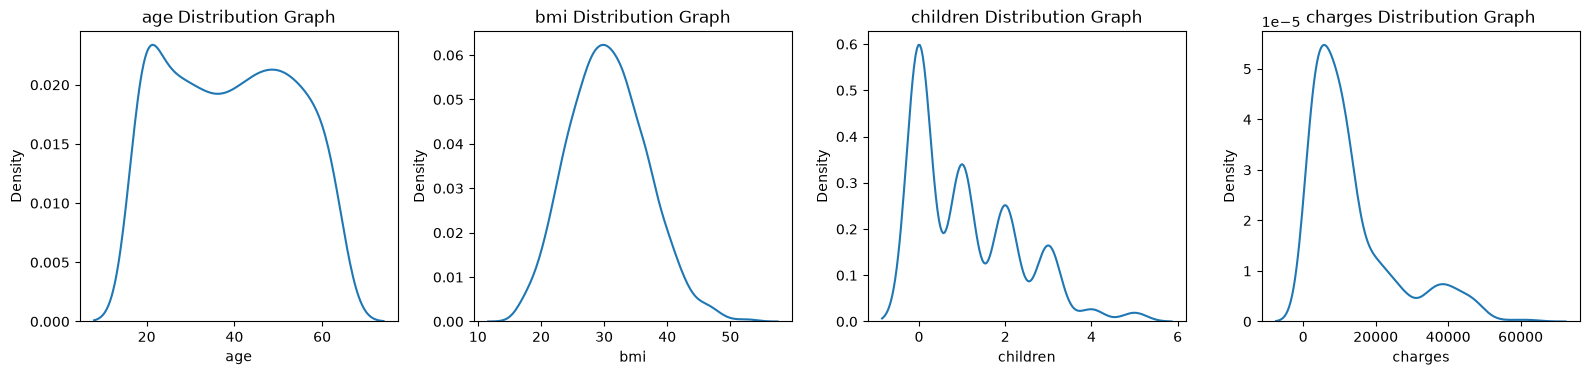

In [44]:

plt.figure(figsize=(16, 4))

for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i + 1)
    sns.kdeplot(df[col])
    plt.title(f"{col} Distribution Graph")

plt.tight_layout()
plt.show()

In [45]:
cat_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns



In [46]:
print(cat_cols)

Index(['sex', 'smoker', 'region'], dtype='str')


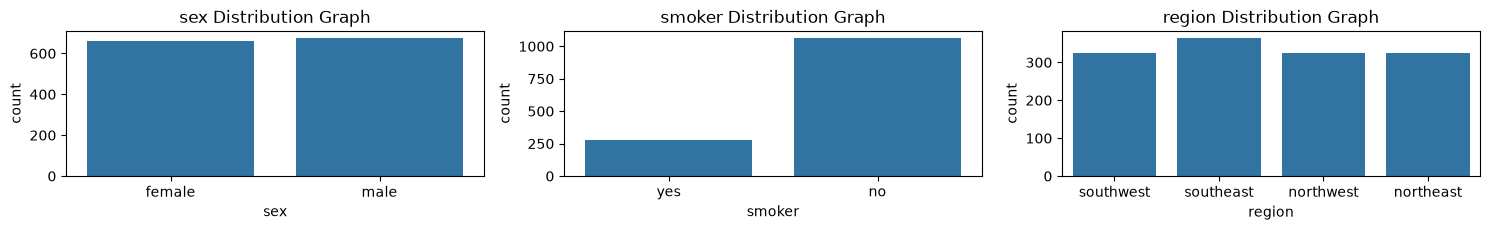

In [47]:
plt.figure(figsize=(15, 4))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution Graph")

plt.tight_layout()
plt.show()

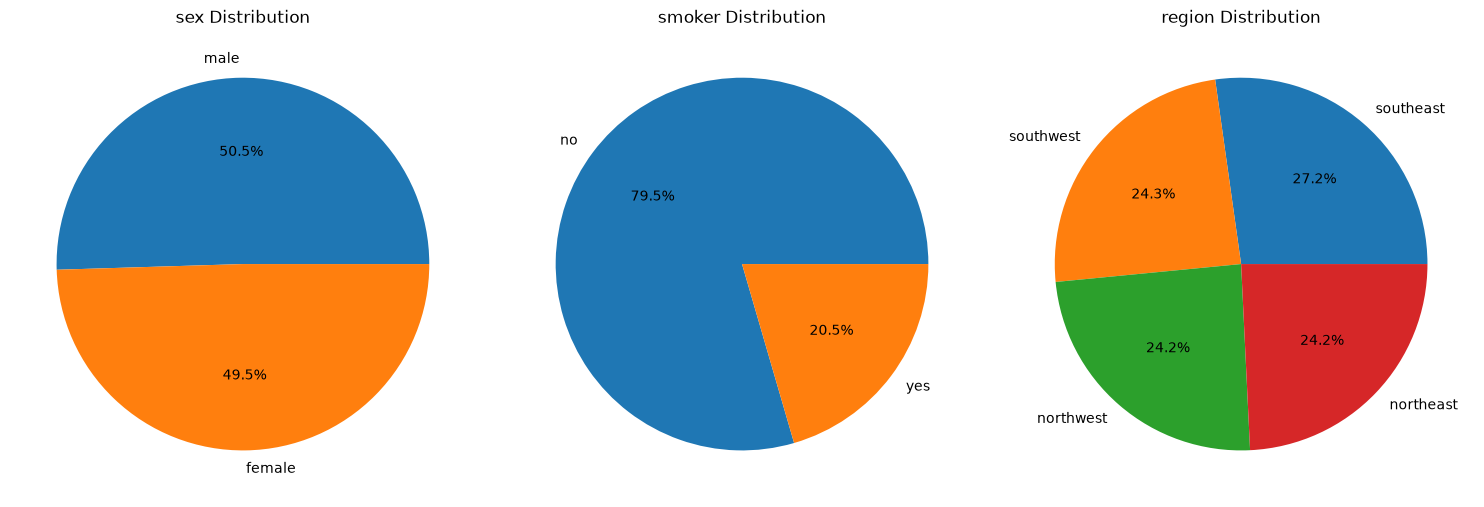

In [48]:

plt.figure(figsize=(15, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()

    plt.subplot(1, 3, i + 1)

    plt.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%"
    )

    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

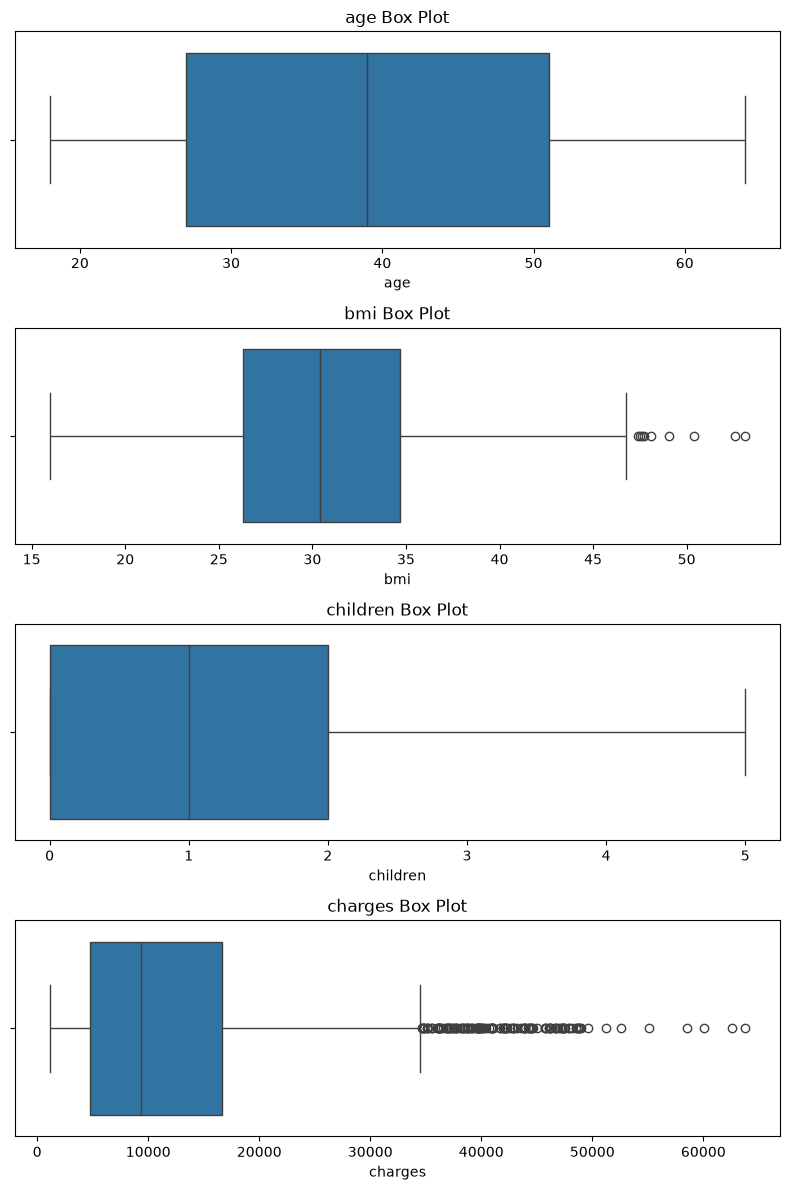

In [49]:
plt.figure(figsize=(8, 12))

for i, col in enumerate(num_cols):

    plt.subplot(4, 1, i + 1)

    sns.boxplot(data=df, x=col, orient="h")

    plt.title(f"{col} Box Plot")

plt.tight_layout()

plt.show()

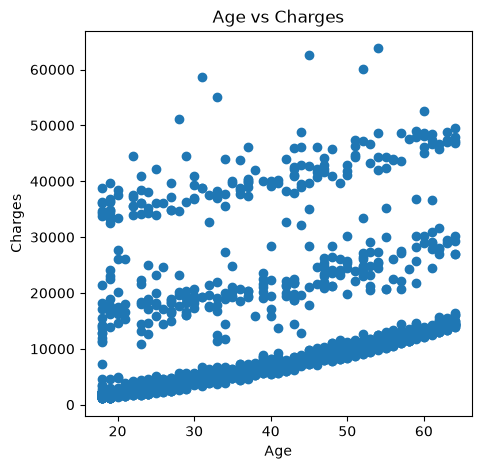

In [50]:
plt.figure(figsize=(5, 5))
plt.scatter(df['age'], df['charges'])
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


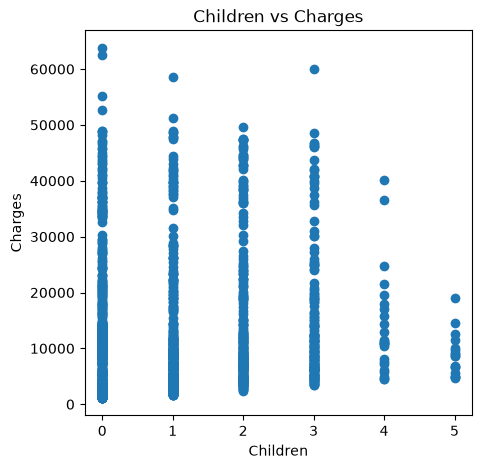

In [51]:
plt.figure(figsize=(5, 5))
plt.scatter(df['children'], df['charges'])
plt.title('Children vs Charges')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.show()

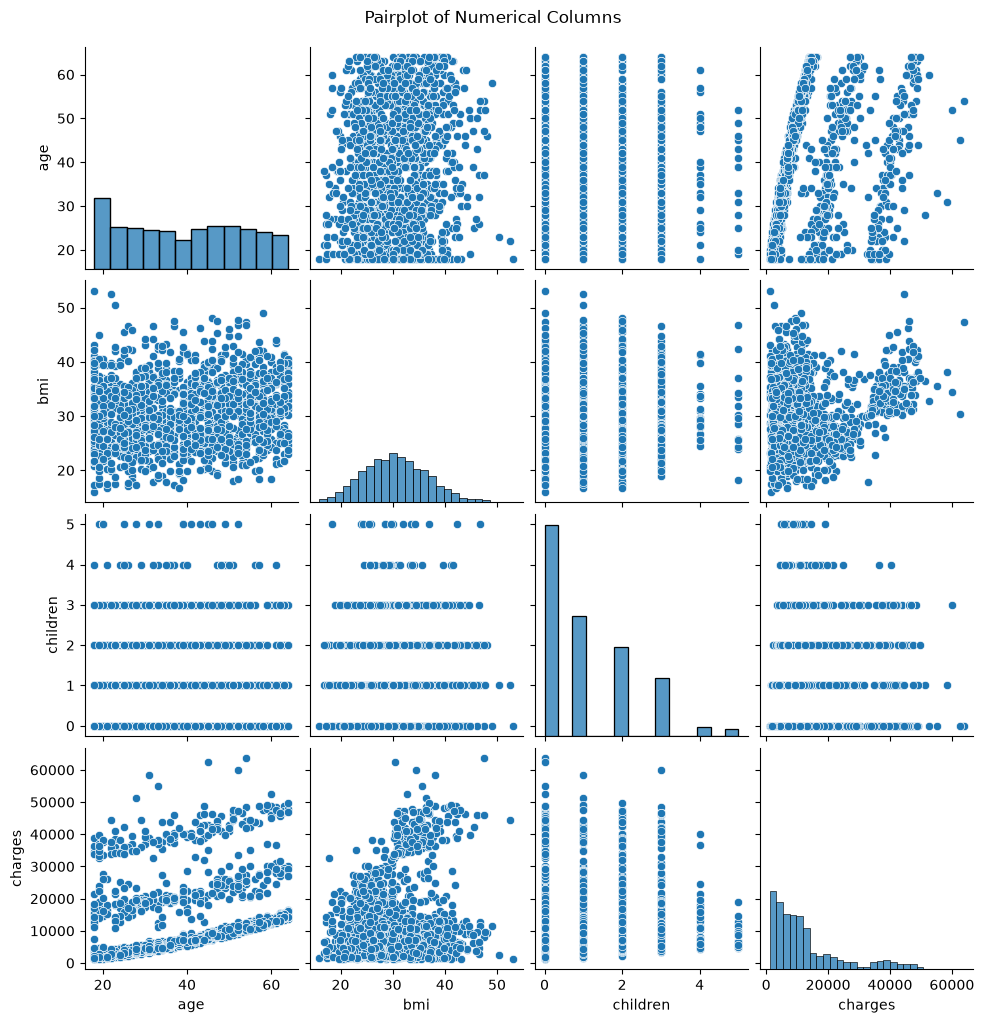

In [52]:


g = sns.pairplot(
    df[num_cols],
    height=2.5
)
g.fig.suptitle(
    "Pairplot of Numerical Columns",
    y=1.02
)

plt.show()

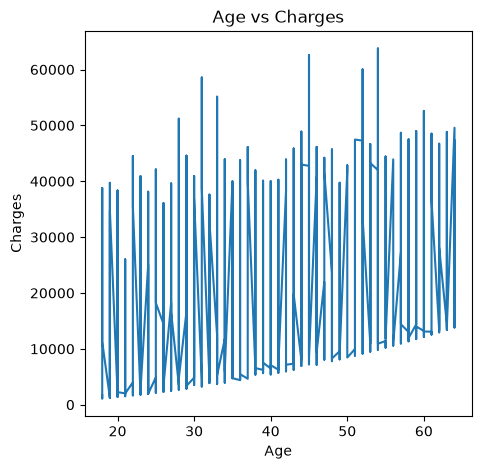

In [53]:
sorted_df = df.sort_values(by="age")

plt.figure(figsize=(5, 5))

plt.plot(sorted_df["age"], sorted_df["charges"])

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")

plt.show()

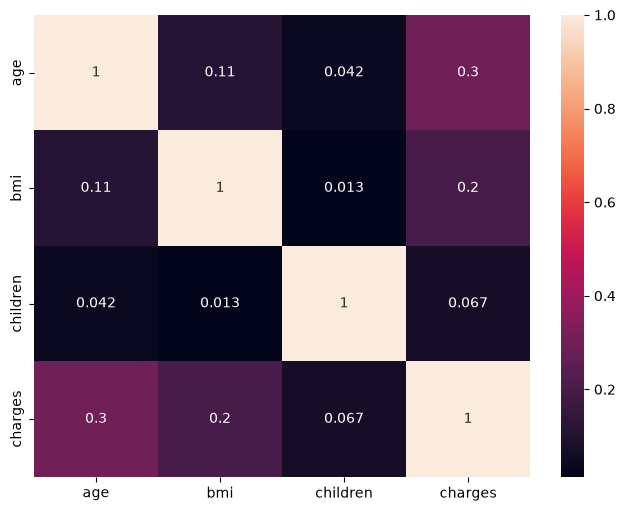

In [54]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

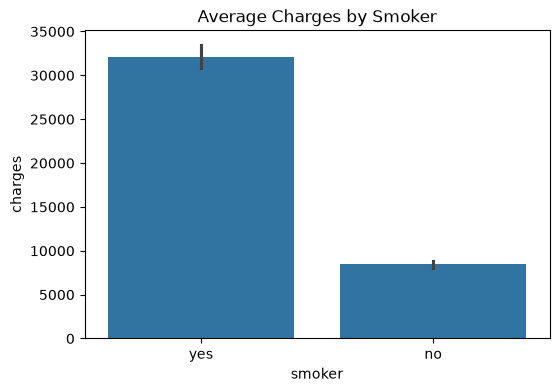

In [55]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x="smoker",
    y="charges",
    data=df
)

plt.title("Average Charges by Smoker")

plt.show()

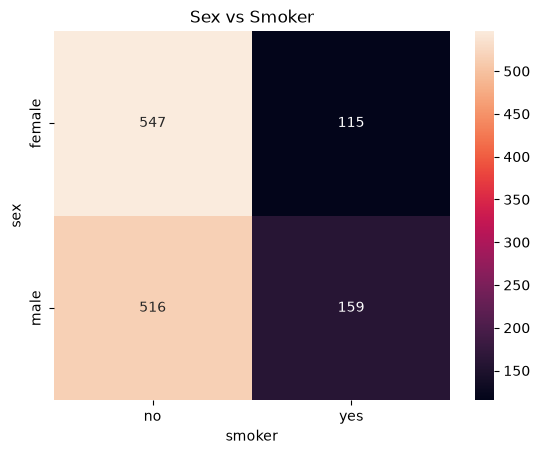

In [56]:
table = pd.crosstab(
    df["sex"],
    df["smoker"]
)

sns.heatmap(
    table,
    annot=True,
    fmt="d"
)

plt.title("Sex vs Smoker")

plt.show()